In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from keras.models import load_model
from dcurves import dca, plot_graphs
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    auc,
    roc_curve,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    brier_score_loss,
)
import matplotlib.pyplot as plt

In [2]:
def evaluate_model(model, test_X, test_y, threshold):
    prob_y = model.predict(test_X)
    pred_y = np.where(prob_y >= threshold, 1, 0)
    print(roc_auc_score(test_y, prob_y))
    print(classification_report(test_y, pred_y))

In [15]:
strategy = "hypophetversion2"
model_name = 'resnet'
model_path1 = Path(
    f"../../model/260320_001228_hypophetversion2/inceptiontime.model.keras"
)
model_path2 = Path(
    f"../../model/260320_170343_hypophetversion2/cnn.model.keras"
)
model_path3 = Path(
    f"../../model/260320_212626_hypophetversion2/resnet.model.keras"
)
model_path4 = Path(
    f"../../model/260320_172006_hypophetversion2/lstmfcn.model.keras"
)
test_path = Path("../../data/mover/06.train_val_test")

In [16]:
X = np.load(test_path / f"mover_{strategy}_test_X.npy")
y = np.load(test_path / f"mover_{strategy}_test_y.npy")
print(X.shape, (y == 1).sum(), (y == 0).sum())

(47005, 3000) 8130 38875


In [17]:
loaded_model1 = load_model(model_path1)
loaded_model2 = load_model(model_path2)
loaded_model3 = load_model(model_path3)
loaded_model4 = load_model(model_path4)

In [19]:
y_prob1 = loaded_model1.predict(X)
y_prob2 = loaded_model2.predict(X)
y_prob3 = loaded_model3.predict(X)
y_prob4 = loaded_model4.predict(X)

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 260s 177ms/step
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 132s 90ms/step


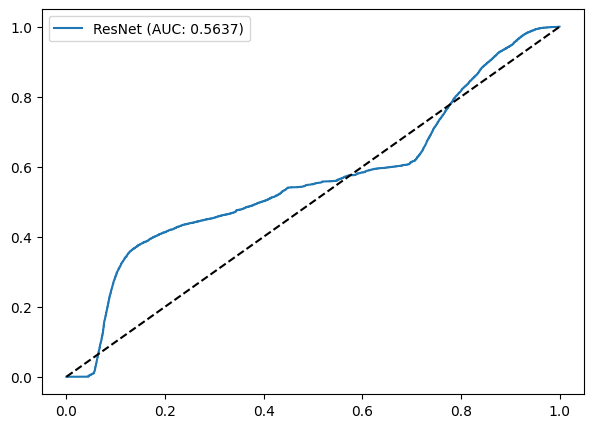

In [10]:
# auroc
fpr, tpr, thr = roc_curve(y, y_prob)
auroc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ResNet (AUC: {auroc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="black")
plt.legend()
plt.show()

In [11]:
# classification
y_pred = np.where(y_prob < 0.6, 0, 1)
print("Threshold: 0.6")
print(classification_report(y, y_pred))

Threshold: 0.6
              precision    recall  f1-score   support

         0.0       0.86      0.75      0.80     38875
         1.0       0.27      0.44      0.33      8130

    accuracy                           0.69     47005
   macro avg       0.56      0.59      0.57     47005
weighted avg       0.76      0.69      0.72     47005



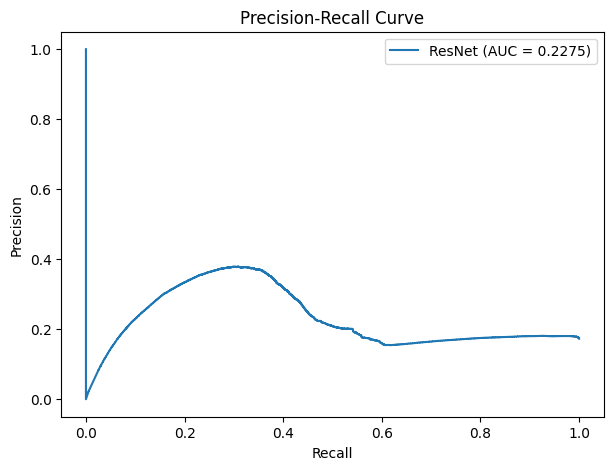

In [12]:
# prauc
prec, recall, prthr = precision_recall_curve(y, y_prob)
prauc = auc(recall, prec)
plt.figure(figsize=(7, 5))
plt.plot(recall, prec, label=f"ResNet (AUC = {prauc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

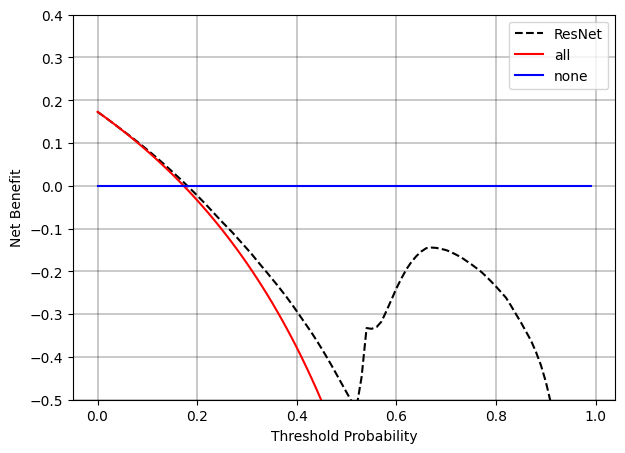

In [13]:
# DCA
thresholds = np.linspace(0, 1, 101)[1:]
dca_result = dca(
    data=pd.DataFrame(
        {
            "outcome": y.reshape(-1),
            f"ResNet": y_prob.reshape(-1)
        }
    ),
    outcome="outcome",
    modelnames=[f"ResNet"],
)

plt.figure(figsize=(7, 5))
plot_graphs(
    plot_df=dca_result.query(f"model.isin(['ResNet', 'all', 'none'])"),
    color_names=("black", "red", "blue"),
    linestyles=("--", "-", "-"),
    y_limits=(-0.5, 0.4),
)

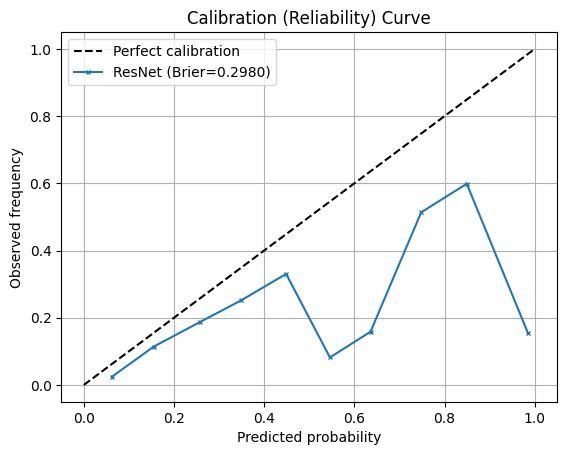

In [14]:
# calibraion
bs = brier_score_loss(y, y_prob)
frac_pos, mean_pred = calibration_curve(y, y_prob, n_bins=10)
plt.figure()
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(
    mean_pred, frac_pos, "x-", label=f"ResNet (Brier={bs:.4f})", markersize=3
)
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.grid(True)
plt.title("Calibration (Reliability) Curve")
plt.show()

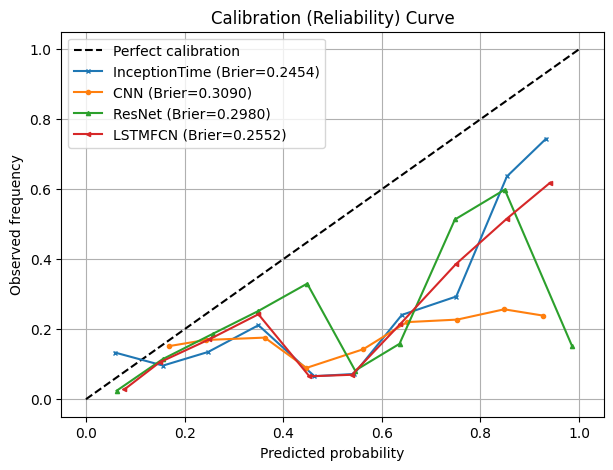

In [24]:
# calibraion
bs1 = brier_score_loss(y, y_prob1)
frac_pos1, mean_pred1 = calibration_curve(y, y_prob1, n_bins=10)
bs2 = brier_score_loss(y, y_prob2)
frac_pos2, mean_pred2 = calibration_curve(y, y_prob2, n_bins=10)
bs3 = brier_score_loss(y, y_prob3)
frac_pos3, mean_pred3 = calibration_curve(y, y_prob3, n_bins=10)
bs4 = brier_score_loss(y, y_prob4)
frac_pos4, mean_pred4 = calibration_curve(y, y_prob4, n_bins=10)

plt.figure(figsize=(7,5))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(
    mean_pred1, frac_pos1, "x-", label=f"InceptionTime (Brier={bs1:.4f})", markersize=3
)
plt.plot(
    mean_pred2, frac_pos2, "o-", label=f"CNN (Brier={bs2:.4f})", markersize=3
)
plt.plot(
    mean_pred3, frac_pos3, "^-", label=f"ResNet (Brier={bs3:.4f})", markersize=3
)
plt.plot(
    mean_pred4, frac_pos4, "<-", label=f"LSTMFCN (Brier={bs4:.4f})", markersize=3
)
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.grid(True)
plt.title("Calibration (Reliability) Curve")
plt.show()